# Comparison of Reconciliation Methods: Stationary vs Non-Stationary Data

This notebook compares the performance of various hierarchical reconciliation methods on synthetic datasets.
We evaluate two scenarios:
1. **Stationary Data**: Homoscedastic residuals.
2. **Non-Stationary Data**: Heteroscedastic residuals (variance increasing over time).

**Methods Evaluated:**
- OLS (Identity)
- MinT (Sample)
- MinT (Shrinkage)
- GS-GLS (Spectral) - Assumes stationarity
- GS-GLS (Wavelet) - Designed for non-stationarity

**Metrics:**
- MSE (Mean Squared Error)
- MAE (Mean Absolute Error)
- Max Incoherence (Structural Consistency Check)
- Execution Time (Inference Only)

In [1]:
import numpy as np
import pandas as pd
import time
import random
import matplotlib.pyplot as plt

from hierarchy import Hierarchy
from data_generator import HierarchicalDataGenerator
from gs_gls import GSGLS
import baselines

%load_ext autoreload
%autoreload 2

## 1. Setup Hierarchy and Data Generators

In [7]:
np.random.seed(42)

# 1. Define Random Hierarchy
def generate_random_hierarchy(depth=4, branching_factor=5):
    structure = {}
    current_layer = ['Total']
    node_ctr = 1
    for d in range(depth):
        next_layer = []
        for parent in current_layer:
            n_children = random.randint(2, branching_factor)
            children = []
            for _ in range(n_children):
                child_name = f'Node_{d+1}_{node_ctr}'
                children.append(child_name)
                node_ctr += 1
            structure[parent] = children
            next_layer.extend(children)
        current_layer = next_layer
    return structure

structure = generate_random_hierarchy()
h = Hierarchy(structure)
print(f"Hierarchy: {h.n_nodes} nodes, {h.m_bottom} bottom nodes.")

# 2. Configuration
n_train = 500
n_test = 100
n_total = n_train + n_test
n_t_block = 10

gen = HierarchicalDataGenerator(h, n_timesteps=n_total)

def get_dataset(heteroscedastic=False):
    Y_true = gen.generate_ground_truth()
    # Generate residuals
    E = gen.generate_spatiotemporal_noise(
        spatial_rho=1.5,
        temporal_ar_coefs=[0.6, 0.2],
        noise_scale=2.0,
        heteroscedastic=heteroscedastic
    )
    Y_hat = Y_true + E
    
    # Split
    residuals_train = E[:, :n_train]
    Y_hat_test = Y_hat[:, n_train:]
    Y_true_test = Y_true[:, n_train:]
    
    return residuals_train, Y_hat_test, Y_true_test, E

# Precompute S matrix for baselines (Spatiotemporal, if needed block-wise)
# Baselines usually just need Spatial S, but MinT needs covariance S_tm x S_sp usually?
# The baseline functions in baselines.py handle Sample/Shrinkage on provided residuals.
S_sp = h.get_summing_matrix()
S_total = baselines.build_spatiotemporal_s(S_sp, n_t_block)

Hierarchy: 263 nodes, 189 bottom nodes.


## 2. Evaluation Helper

In [8]:
def evaluate_methods(scenario_name, residuals_train, Y_hat_test, Y_true_test):
    results = []
    
    # Prepare MinT samples (Vectorize blocks for covariance estimation)
    # baselines.mint_* expects (n_samples, n_features)
    # Here features = n_nodes * n_t_block
    train_blocks = []
    for i in range(0, residuals_train.shape[1] - n_t_block + 1, n_t_block):
        block = residuals_train[:, i:i+n_t_block]
        train_blocks.append(block.flatten(order='F'))
    residuals_samples = np.array(train_blocks)
    
    # Define Methods
    methods = [
        ('OLS', baselines.ols_identity, False),
        ('MinT (Sample)', baselines.mint_sample, True),
        ('MinT (Shrinkage)', baselines.mint_shrink, True),
    ]
    
    # 1. Run Baselines
    for name, func, needs_train in methods:
        start_t = time.time()
        
        mse_list, mae_list, incoh_list = [], [], []
        
        # Iterate test blocks
        for i in range(0, Y_hat_test.shape[1] - n_t_block + 1, n_t_block):
            y_hat_blk = Y_hat_test[:, i:i+n_t_block]
            y_true_blk = Y_true_test[:, i:i+n_t_block]
            y_hat_flat = y_hat_blk.flatten(order='F')
            
            try:
                if needs_train:
                    y_tilde_flat = func(y_hat_flat, residuals_samples, S_total)
                else:
                    y_tilde_flat = func(y_hat_flat, S_total)
                
                y_tilde_blk = y_tilde_flat.reshape((h.n_nodes, n_t_block), order='F')
                
                # Metrics
                mse_list.append(np.mean((y_tilde_blk - y_true_blk)**2))
                mae_list.append(np.mean(np.abs(y_tilde_blk - y_true_blk)))
                
                # Incoherence (Max violation of S*y_bottom = y_total)
                # We check for every parent
                max_viol = 0.0
                for p, children in h.structure.items():
                    p_idx = h.node_to_idx[p]
                    c_idxs = [h.node_to_idx[c] for c in children]
                    agg = np.sum(y_tilde_blk[c_idxs, :], axis=0)
                    diff = np.max(np.abs(y_tilde_blk[p_idx, :] - agg))
                    if diff > max_viol: max_viol = diff
                incoh_list.append(max_viol)
                
            except Exception as e:
                print(f"Error in {name}: {e}")
                break
        
        duration = time.time() - start_t
        results.append({
            'Scenario': scenario_name,
            'Method': name,
            'MSE': np.mean(mse_list) if mse_list else np.nan,
            'MAE': np.mean(mae_list) if mae_list else np.nan,
            'Max_Incoherence': np.mean(incoh_list) if incoh_list else np.nan,
            'Time': duration
        })

    # 2. Run GS-GLS (Spectral)
    print("Training GS-GLS (Spectral)...")
    gs_spec = GSGLS(h, temporal_method='spectral')
    gs_spec.fit(residuals_train)
    
    print("Reconciling GS-GLS (Spectral)...")
    start_t = time.time()
    mse_list, mae_list, incoh_list = [], [], []
    for i in range(0, Y_hat_test.shape[1] - n_t_block + 1, n_t_block):
        y_hat_blk = Y_hat_test[:, i:i+n_t_block]
        y_true_blk = Y_true_test[:, i:i+n_t_block]
        y_tilde_blk = gs_spec.reconcile(y_hat_blk)
        
        mse_list.append(np.mean((y_tilde_blk - y_true_blk)**2))
        mae_list.append(np.mean(np.abs(y_tilde_blk - y_true_blk)))
        
        max_viol = 0.0
        for p, children in h.structure.items():
            p_idx = h.node_to_idx[p]
            c_idxs = [h.node_to_idx[c] for c in children]
            agg = np.sum(y_tilde_blk[c_idxs, :], axis=0)
            diff = np.max(np.abs(y_tilde_blk[p_idx, :] - agg))
            if diff > max_viol: max_viol = diff
        incoh_list.append(max_viol)
        
    duration = time.time() - start_t
    results.append({
        'Scenario': scenario_name,
        'Method': 'GS-GLS (Spectral)',
        'MSE': np.mean(mse_list),
        'MAE': np.mean(mae_list),
        'Max_Incoherence': np.mean(incoh_list),
        'Time': duration
    })
    
    # 3. Run GS-GLS (Wavelet)
    print("Training GS-GLS (Wavelet)...")
    gs_wav = GSGLS(h, temporal_method='wavelet')
    gs_wav.fit(residuals_train)
    
    print("Reconciling GS-GLS (Wavelet)...")
    start_t = time.time()
    mse_list, mae_list, incoh_list = [], [], []
    for i in range(0, Y_hat_test.shape[1] - n_t_block + 1, n_t_block):
        y_hat_blk = Y_hat_test[:, i:i+n_t_block]
        y_true_blk = Y_true_test[:, i:i+n_t_block]
        y_tilde_blk = gs_wav.reconcile(y_hat_blk)
        
        mse_list.append(np.mean((y_tilde_blk - y_true_blk)**2))
        mae_list.append(np.mean(np.abs(y_tilde_blk - y_true_blk)))
        
        max_viol = 0.0
        for p, children in h.structure.items():
            p_idx = h.node_to_idx[p]
            c_idxs = [h.node_to_idx[c] for c in children]
            agg = np.sum(y_tilde_blk[c_idxs, :], axis=0)
            diff = np.max(np.abs(y_tilde_blk[p_idx, :] - agg))
            if diff > max_viol: max_viol = diff
        incoh_list.append(max_viol)
        
    duration = time.time() - start_t
    results.append({
        'Scenario': scenario_name,
        'Method': 'GS-GLS (Wavelet)',
        'MSE': np.mean(mse_list),
        'MAE': np.mean(mae_list),
        'Max_Incoherence': np.mean(incoh_list),
        'Time': duration
    })
    
    return pd.DataFrame(results)

## 3. Scenario 1: Stationary Data
In this scenario, residual variance is constant over time.

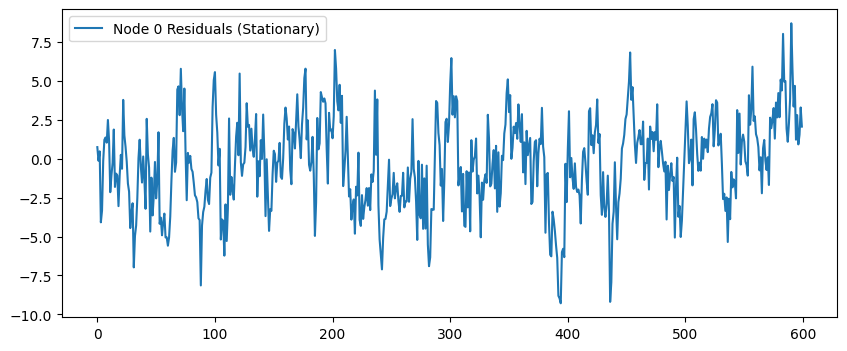

Training GS-GLS (Spectral)...
Reconciling GS-GLS (Spectral)...
Training GS-GLS (Wavelet)...
Reconciling GS-GLS (Wavelet)...
Stationary Results:


,Scenario,Method,MSE,MAE,Max_Incoherence,Time
0,Stationary,OLS,6.692058,2.036846,8.003553e-12,37.118850
1,Stationary,MinT (Sample),7.867799,2.231623,1.091394e-10,30.647900
2,Stationary,MinT (Shrinkage),6.727436,2.041414,9.895302e-11,27.904157
3,Stationary,GS-GLS (Spectral),5.171396,1.809456,2.546585e-11,0.017599
4,Stationary,GS-GLS (Wavelet),5.171396,1.809456,2.546585e-11,0.016947


In [9]:
# Generate Data
res_train_stat, Y_hat_stat, Y_true_stat, E_stat = get_dataset(heteroscedastic=False)

# Display one series to see homoscedasticity
plt.figure(figsize=(10, 4))
plt.plot(E_stat[0, :], label='Node 0 Residuals (Stationary)')
plt.legend()
plt.show()

# Run Evaluation
df_stat = evaluate_methods("Stationary", res_train_stat, Y_hat_stat, Y_true_stat)
print("Stationary Results:")
display(df_stat)

## 4. Scenario 2: Non-Stationary Data
In this scenario, residual variance increases linearly over time (Heteroscedasticity).

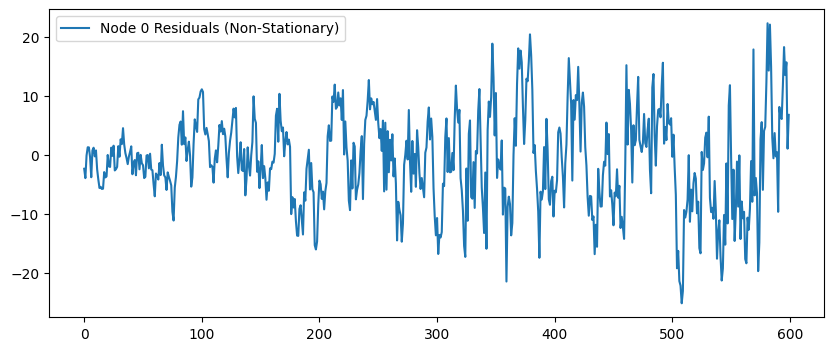

Training GS-GLS (Spectral)...
Reconciling GS-GLS (Spectral)...
Training GS-GLS (Wavelet)...
Reconciling GS-GLS (Wavelet)...
Non-Stationary Results:


,Scenario,Method,MSE,MAE,Max_Incoherence,Time
0,Non-Stationary,OLS,99.480938,7.833551,6.730261e-12,43.625844
1,Non-Stationary,MinT (Sample),116.130544,8.556728,1.251465e-10,41.036126
2,Non-Stationary,MinT (Shrinkage),99.399439,7.846802,9.022187e-11,29.336751
3,Non-Stationary,GS-GLS (Spectral),75.067405,6.884177,2.401066e-11,0.035456
4,Non-Stationary,GS-GLS (Wavelet),75.067405,6.884177,2.401066e-11,0.036996


In [10]:
# Generate Data
res_train_nonstat, Y_hat_nonstat, Y_true_nonstat, E_nonstat = get_dataset(heteroscedastic=True)

# Display one series to see heteroscedasticity
plt.figure(figsize=(10, 4))
plt.plot(E_nonstat[0, :], label='Node 0 Residuals (Non-Stationary)')
plt.legend()
plt.show()

# Run Evaluation
df_nonstat = evaluate_methods("Non-Stationary", res_train_nonstat, Y_hat_nonstat, Y_true_nonstat)
print("Non-Stationary Results:")
display(df_nonstat)

## 5. Summary

Comparing the two tables below. We expect **GS-GLS (Wavelet)** to outperform or match Spectral on stationary data, but significantly outperform Spectral on Non-Stationary data.

In [11]:
df_all = pd.concat([df_stat, df_nonstat], ignore_index=True)
df_all.sort_values(by=['Scenario', 'MSE'], inplace=True)
df_all

,Scenario,Method,MSE,MAE,Max_Incoherence,Time
8,Non-Stationary,GS-GLS (Spectral),75.067405,6.884177,2.401066e-11,0.035456
9,Non-Stationary,GS-GLS (Wavelet),75.067405,6.884177,2.401066e-11,0.036996
7,Non-Stationary,MinT (Shrinkage),99.399439,7.846802,9.022187e-11,29.336751
5,Non-Stationary,OLS,99.480938,7.833551,6.730261e-12,43.625844
6,Non-Stationary,MinT (Sample),116.130544,8.556728,1.251465e-10,41.036126
3,Stationary,GS-GLS (Spectral),5.171396,1.809456,2.546585e-11,0.017599
4,Stationary,GS-GLS (Wavelet),5.171396,1.809456,2.546585e-11,0.016947
0,Stationary,OLS,6.692058,2.036846,8.003553e-12,37.118850
2,Stationary,MinT (Shrinkage),6.727436,2.041414,9.895302e-11,27.904157
1,Stationary,MinT (Sample),7.867799,2.231623,1.091394e-10,30.647900
